In [1]:
!git config --global user.email "your-email@gmail.com"
!git config --global user.name "siddhi1991"

In [2]:
!git clone https://github.com/siddhi1991/GeoAI.git

Cloning into 'GeoAI'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 16.17 MiB | 15.58 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
%pip install geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/1

In [ ]:
import geoai

In [ ]:
train_raster_url = ("/content/image_train.tif")
train_vector_url = ("/content/buildings.geojson")
test_raster_url = ("/content/image_test.tif")

In [ ]:
train_raster_path = train_raster_url
train_vector_path = train_vector_url
test_raster_path = geoai.download_file(test_raster_url)

File already exists: image_test.tif


===== RASTER INFORMATION: /content/image_train.tif =====
Driver: GTiff
Dimensions: 936 x 860 pixels
Number of bands: 4
Data type: uint8
Coordinate Reference System: EPSG:26917
Georeferenced Bounds: BoundingBox(left=227515.90840000007, bottom=4403031.1548999995, right=227796.41550000012, top=4403288.9311999995)
Pixel Resolution: 0.3, 0.3
NoData Value: 255.0

----- Band Statistics -----
Band 1:
  Min: 18.00
  Max: 254.00
  Mean: 120.98
  Std Dev: 34.70
Band 2:
  Min: 18.00
  Max: 254.00
  Mean: 128.32
  Std Dev: 27.52
Band 3:
  Min: 18.00
  Max: 254.00
  Mean: 124.47
  Std Dev: 22.00
Band 4:
  Min: 18.00
  Max: 254.00
  Mean: 170.40
  Std Dev: 32.75


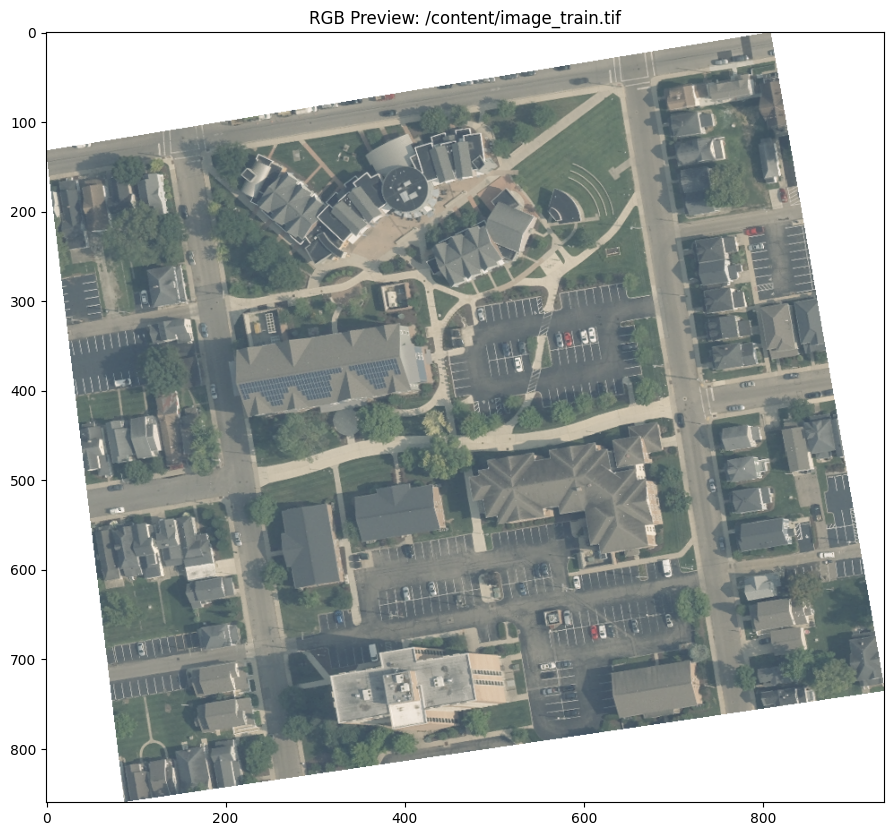

In [ ]:
geoai.print_raster_info(train_raster_path, figsize=(18, 10))

===== VECTOR INFORMATION: /content/buildings.geojson =====
Driver: GEOJSON
Feature count: 91
Geometry types: {'Polygon': 91}
Coordinate Reference System: EPSG:4326
Bounds: [-84.1806502, 39.73353, -84.1765333, 39.7358426]
Number of attributes: 23
Attribute names: id, bbox, version, sources, level, subtype, class, height, names, has_parts, is_underground, num_floors, num_floors_underground, min_height, min_floor, facade_color, facade_material, roof_material, roof_shape, roof_direction, roof_orientation, roof_color, roof_height

----- Attribute Statistics -----
Attribute: version
  min: 1
  max: 3
  mean: 1.8681
  std: 0.4991
  null_count: 0
Attribute: height
  min: 2.2195
  max: 29.7944
  mean: 5.6148
  std: 3.3598
  null_count: 18
Attribute: num_floors
  min: 12.0000
  max: 12.0000
  mean: 12.0000
  std: nan
  null_count: 90


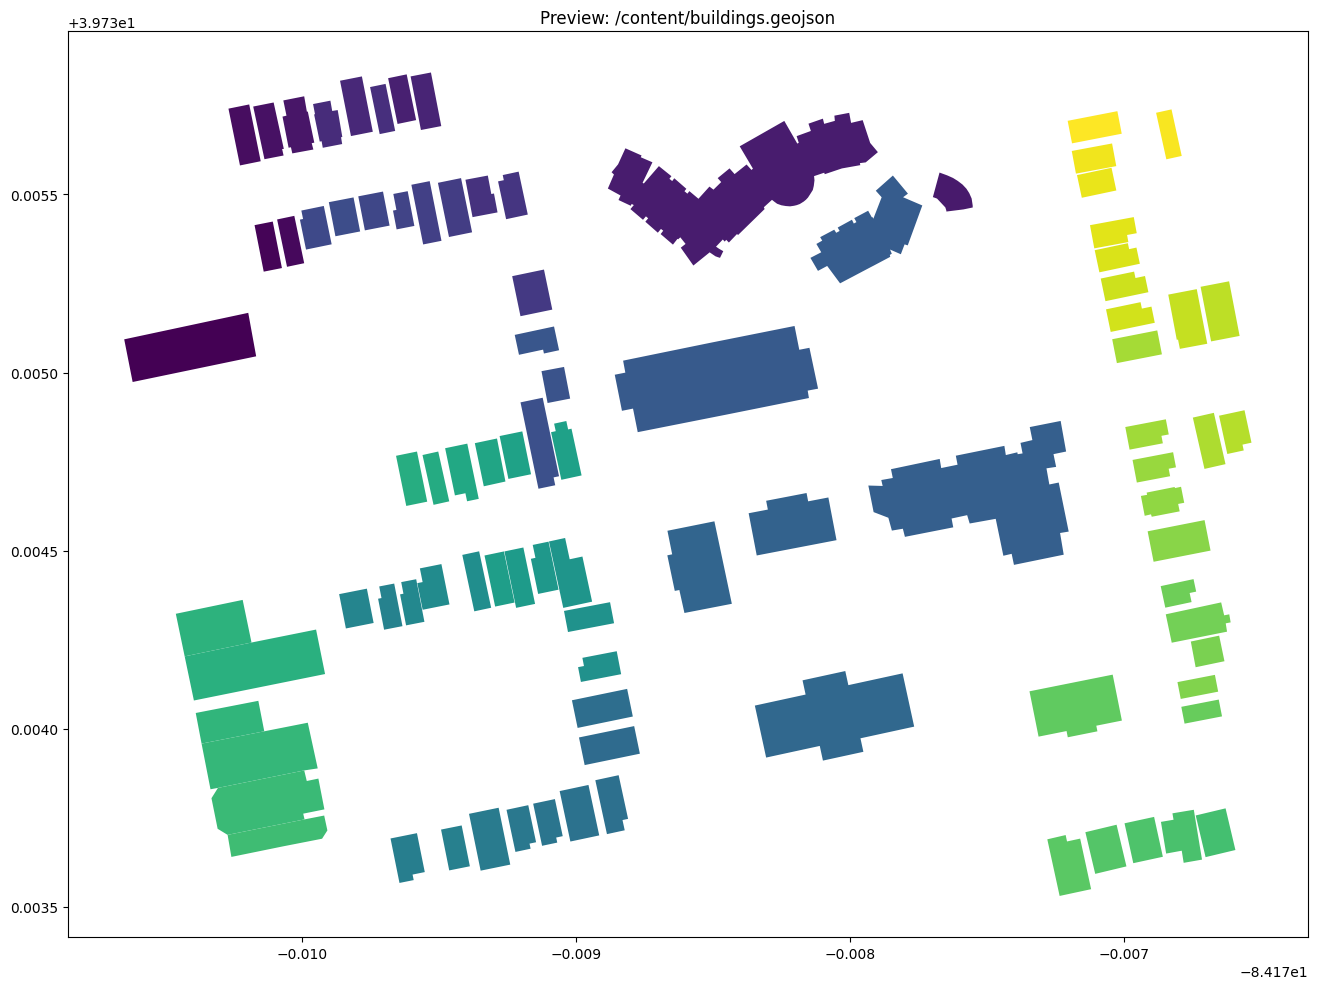

In [ ]:
geoai.print_vector_info(train_vector_path, figsize=(18, 10))

In [ ]:
geoai.view_vector_interactive(train_vector_path, tiles=train_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
out_folder = "output"
tiles = geoai.export_geotiff_tiles(
in_raster=train_raster_path,
out_folder=out_folder,
in_class_data=train_vector_path,
tile_size=512,
stride=256,
buffer_radius=0,
)


Raster info for /content/image_train.tif:
  CRS: EPSG:26917
  Dimensions: 936 x 860
  Resolution: (0.299687072649622, 0.29973988372096144)
  Bands: 4
  Bounds: BoundingBox(left=227515.90840000007, bottom=4403031.1548999995, right=227796.41550000012, top=4403288.9311999995)
Loaded 91 features from /content/buildings.geojson
Vector CRS: EPSG:4326
Reprojecting features from EPSG:4326 to EPSG:26917
Found 6 unique classes: [None 'house' 'roof' 'apartments' 'commercial' 'garage']


Generated: 9, With features: 9: 100%|██████████| 9/9 [00:00<00:00, 19.99it/s]


------- Export Summary -------
Total tiles exported: 9
Tiles with features: 9 (100.0%)
Average feature pixels per tile: 54836.4
Output saved to: output

------- Georeference Verification -------


In [ ]:
geoai.train_MaskRCNN_model(
images_dir=f"{out_folder}/images",
labels_dir=f"{out_folder}/labels",
output_dir=f"{out_folder}/models",
num_channels=4,
pretrained=True,
batch_size=4,
num_epochs=10,
learning_rate=0.001,
val_split=0.2,
)

Using device: cuda
Found 9 image files and 9 label files
Training on 7 images, validating on 2 images
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 197MB/s]


Epoch: 1, Batch: 1/2, Loss: 6.5471, Time: 3.68s
Epoch 1/10: Train Loss: 4.9560, Val Loss: inf, Val IoU: 0.2240
Saving best model with IoU: 0.2240
Epoch: 2, Batch: 1/2, Loss: 2.6671, Time: 1.93s
Epoch 2/10: Train Loss: 2.7481, Val Loss: inf, Val IoU: 0.2247
Saving best model with IoU: 0.2247
Epoch: 3, Batch: 1/2, Loss: 2.6183, Time: 1.95s
Epoch 3/10: Train Loss: 2.4580, Val Loss: inf, Val IoU: 0.2553
Saving best model with IoU: 0.2553
Epoch: 4, Batch: 1/2, Loss: 2.1502, Time: 1.95s
Epoch 4/10: Train Loss: 2.1542, Val Loss: inf, Val IoU: 0.3030
Saving best model with IoU: 0.3030
Epoch: 5, Batch: 1/2, Loss: 2.1172, Time: 1.95s
Epoch 5/10: Train Loss: 2.0453, Val Loss: inf, Val IoU: 0.3273
Saving best model with IoU: 0.3273
Epoch: 6, Batch: 1/2, Loss: 1.9690, Time: 1.97s
Epoch 6/10: Train Loss: 2.0541, Val Loss: inf, Val IoU: 0.3747
Saving best model with IoU: 0.3747
Epoch: 7, Batch: 1/2, Loss: 1.9779, Time: 2.01s
Epoch 7/10: Train Loss: 1.9203, Val Loss: inf, Val IoU: 0.3660
Epoch: 8, Bat

In [ ]:
masks_path = "naip_test_prediction.tif"
model_path = f"{out_folder}/models/best_model.pth"
geoai.object_detection(
test_raster_path,
masks_path,
model_path,
window_size=512,
overlap=256,
confidence_threshold=0.5,
batch_size=4,
num_channels=4,
)

Processing 4 windows with size 512x512 and overlap 256...


9it [00:01,  5.37it/s]

Inference completed in 1.68 seconds
Saved prediction to naip_test_prediction.tif


In [ ]:
output_path = "naip_test_prediction.geojson"
buildings_gdf = geoai.raster_to_vector(masks_path, output_path)
buildings_gdf

Vectorized data saved to naip_test_prediction.geojson


,geometry,class
0,"POLYGON ((228087.444 4402066.493, 228087.444 4...",1
1,"POLYGON ((228107.831 4402064.993, 228107.831 4...",1
2,"POLYGON ((228136.613 4402064.393, 228136.613 4...",1
3,"POLYGON ((228116.826 4402064.393, 228116.826 4...",1
4,"POLYGON ((228214.864 4402056.594, 228214.864 4...",1
5,"POLYGON ((228180.985 4402068.293, 228180.985 4...",1
6,"POLYGON ((228095.839 4402056.294, 228095.839 4...",1
7,"POLYGON ((228230.155 4402054.794, 228230.155 4...",1
8,"POLYGON ((228253.54 4402052.394, 228253.54 440...",1
9,"POLYGON ((228113.228 4402046.095, 228113.228 4...",1


In [ ]:
geoai.view_vector_interactive(buildings_gdf, tiles=test_raster_url)

In [ ]:
regularized_gdf = geoai.regularize(
data=buildings_gdf,
simplify_tolerance=2.0,
allow_45_degree=True,
diagonal_threshold_reduction=30,
allow_circles=True,
circle_threshold=0.9,
)

In [ ]:
geoai.view_vector_interactive(regularized_gdf, tiles=test_raster_url)

In [ ]:
geoai.create_split_map(
left_layer=regularized_gdf,
right_layer=test_raster_url,
left_label="Regularized Buildings",
right_label="NAIP Imagery",
left_args={"style": {"color": "red", "fillOpacity": 0.3}},
basemap=test_raster_url,
)

Map(center=[39.7246325, -84.171432], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…